<a href="https://colab.research.google.com/github/IshiPareek/merch_interpet/blob/main/01_gpt2_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 — imports
!pip install transformer_lens
import transformer_lens
from transformer_lens import HookedTransformer
import torch
import numpy as np

print(f"TransformerLens installd")
print(f"CUDA available: {torch.cuda.is_available()}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 945.3/945.3 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.4 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=b5a10afe80ce6b4a87c04ac0349ef2937da693e567d4c5f7d8ac399899fe155a
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
TransformerLens installd
CUDA available: False


In [ ]:
model = HookedTransformer.from_pretrained("gpt2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer


In [ ]:
tokens = model.to_tokens("The meaning of life is")
str_tokens = model.to_str_tokens(tokens)
print(model.to_str_tokens(tokens))
logits = model(tokens)
print(logits.shape)

['<|endoftext|>', 'The', ' meaning', ' of', ' life', ' is']
torch.Size([1, 6, 50257])


In [ ]:
# ── VISUALIZATION BOILERPLATE ── define once, call anywhere ──────────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def viz(cache, plot_type, layer=0, head=0, dims=64, model=model, str_tokens=str_tokens):
    """
    Universal cache visualizer.

    plot_type options:
        "embed"      → token embeddings
        "pos_embed"  → positional embeddings
        "pattern"    → attention pattern for one head
        "all_heads"  → all 12 heads in a layer
        "resid"      → residual stream at a layer
        "logit_lens" → top predicted token across all layers
        "qkv"        → query, key, value vectors
    """

    def heatmap(ax, matrix, title, row_labels=None, cmap="RdBu_r"):
        vmax = np.abs(matrix).max()
        ax.imshow(matrix, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_title(title, fontsize=10, pad=6)
        if row_labels:
            ax.set_yticks(range(len(row_labels)))
            ax.set_yticklabels(row_labels, fontsize=8)
        else:
            ax.set_yticks([])
        ax.set_xticks([])

    # ── embed ────────────────────────────────────────────────────────────────
    if plot_type == "embed":
        data = cache["hook_embed"][0, :, :dims].detach().numpy()
        fig, ax = plt.subplots(figsize=(14, 3))
        heatmap(ax, data, f"hook_embed — first {dims} dims", row_labels=str_tokens)
        plt.tight_layout(); plt.show()

    # ── pos_embed ────────────────────────────────────────────────────────────
    elif plot_type == "pos_embed":
        data = cache["hook_pos_embed"][0, :, :dims].detach().numpy()
        fig, ax = plt.subplots(figsize=(14, 3))
        heatmap(ax, data, f"hook_pos_embed — first {dims} dims", row_labels=str_tokens, cmap="PiYG")
        plt.tight_layout(); plt.show()

    # ── pattern ──────────────────────────────────────────────────────────────
    elif plot_type == "pattern":
        data = cache[f"blocks.{layer}.attn.hook_pattern"][0, head].detach().numpy()
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.imshow(data, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(str_tokens))); ax.set_xticklabels(str_tokens, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(str_tokens))); ax.set_yticklabels(str_tokens, fontsize=8)
        ax.set_title(f"attention pattern — layer {layer}, head {head}", fontsize=10)
        plt.tight_layout(); plt.show()

    # ── all_heads ────────────────────────────────────────────────────────────
    elif plot_type == "all_heads":
        fig, axes = plt.subplots(3, 4, figsize=(14, 9))
        for h, ax in enumerate(axes.flat):
            data = cache[f"blocks.{layer}.attn.hook_pattern"][0, h].detach().numpy()
            ax.imshow(data, cmap="Blues", vmin=0, vmax=1)
            ax.set_title(f"H{h}", fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
        fig.suptitle(f"all attention heads — layer {layer}", fontsize=12)
        plt.tight_layout(); plt.show()

    # ── resid ────────────────────────────────────────────────────────────────
    elif plot_type == "resid":
        data = cache[f"blocks.{layer}.hook_resid_post"][0, :, :dims].detach().numpy()
        fig, ax = plt.subplots(figsize=(14, 3))
        heatmap(ax, data, f"hook_resid_post — layer {layer}, first {dims} dims", row_labels=str_tokens)
        plt.tight_layout(); plt.show()

    # ── logit_lens ───────────────────────────────────────────────────────────
    elif plot_type == "logit_lens":
        n_layers = model.cfg.n_layers
        cell_text = []
        for l in range(n_layers):
            resid = cache[f"blocks.{l}.hook_resid_post"]
            top = model.unembed(model.ln_final(resid))[0, :, :].argmax(dim=-1)
            cell_text.append([model.to_string(t) for t in top])
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.axis("off")
        tbl = ax.table(cellText=cell_text, rowLabels=[f"L{l}" for l in range(n_layers)],
                       colLabels=str_tokens, loc="center", cellLoc="center")
        tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.3)
        ax.set_title("logit lens — top predicted token per layer × position", fontsize=11, pad=20)
        plt.tight_layout(); plt.show()

    # ── qkv ──────────────────────────────────────────────────────────────────
    elif plot_type == "qkv":
        fig, axes = plt.subplots(1, 3, figsize=(14, 3))
        for ax, key, label in zip(axes, ["hook_q","hook_k","hook_v"], ["Query","Key","Value"]):
            data = cache[f"blocks.{layer}.attn.{key}"][0, :, head, :].detach().numpy()
            heatmap(ax, data, f"{label} — layer {layer}, head {head}", row_labels=str_tokens)
        plt.tight_layout(); plt.show()

    else:
        print(f"unknown plot_type '{plot_type}'. options: embed, pos_embed, pattern, all_heads, resid, logit_lens, qkv")

In [ ]:
logits, cache = model.run_with_cache(tokens, remove_batch_dim=True)
print(list(cache.keys())[:10])

['hook_embed', 'hook_pos_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.attn.hook_q', 'blocks.0.attn.hook_k', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern']


In [ ]:
resid_mid = cache["blocks.5.hook_resid_post"]
print(resid_mid.shape)

torch.Size([6, 768])


In [ ]:
cache ['hook_embed']
#print(model.to_str_tokens(tokens))

tensor([[ 0.0517, -0.0274,  0.0502,  ...,  0.0074,  0.1555,  0.1210],
        [-0.0673, -0.0190,  0.0658,  ...,  0.0652, -0.0086,  0.0044],
        [ 0.1664, -0.0845,  0.0136,  ..., -0.0570, -0.2040, -0.0840],
        [-0.0553,  0.0202,  0.0353,  ..., -0.0669, -0.0911, -0.0694],
        [ 0.2127,  0.1371,  0.0176,  ..., -0.0269, -0.0258, -0.1626],
        [-0.0078,  0.0120,  0.0575,  ...,  0.1164, -0.0361, -0.0234]])

In [ ]:
cache ["hook_pos_embed"]

tensor([[-0.0134, -0.1920,  0.0095,  ..., -0.0376,  0.0337,  0.0599],
        [ 0.0250, -0.0528, -0.0939,  ...,  0.0352,  0.0112,  0.0009],
        [ 0.0065, -0.0825,  0.0568,  ...,  0.0220,  0.0216, -0.0192],
        [ 0.0022, -0.0713,  0.1080,  ...,  0.0126,  0.0201, -0.0046],
        [ 0.0100, -0.0227,  0.1293,  ...,  0.0108,  0.0122, -0.0047],
        [ 0.0119, -0.0316,  0.1335,  ...,  0.0082,  0.0094, -0.0052]])

In [ ]:
cache ['blocks.1.hook_resid_pre']


tensor([[ 0.3091,  0.0722,  0.5184,  ...,  1.6378,  1.6544,  0.3109],
        [-1.3148, -0.3303, -0.7729,  ..., -0.3829, -0.5143,  0.2858],
        [-0.9259,  1.3713, -1.4814,  ...,  0.2881,  0.5344,  0.5701],
        [ 2.0818,  1.0211,  0.1810,  ..., -0.5893,  0.1366,  0.5420],
        [-0.3084,  2.3778, -0.2061,  ..., -1.4559, -1.5761, -2.2761],
        [-0.9501,  0.6804, -0.4359,  ...,  0.9668, -0.4264,  1.2755]])

In [ ]:
cache ['blocks.2.hook_resid_pre']

tensor([[-0.6453, -0.7704, -0.1232,  ...,  0.8834,  0.6387, -0.0287],
        [-0.9452, -0.3306, -0.9315,  ..., -0.2940, -1.3289, -0.0977],
        [-0.8624,  1.6325, -1.2146,  ...,  0.9131,  0.4301,  0.4241],
        [ 2.0411,  1.5203,  0.4327,  ..., -0.5435, -0.0243,  0.1584],
        [-0.2051,  3.0154,  0.5819,  ..., -1.0258, -1.8866, -3.4099],
        [-0.6446,  0.9260, -0.8152,  ...,  1.1363, -0.2344,  1.3691]])

In [ ]:
logits, cache = model.run_with_cache(tokens)
cache ['blocks.2.hook_resid_pre']

tensor([[[-0.6453, -0.7704, -0.1232,  ...,  0.8834,  0.6387, -0.0287],
         [-0.9452, -0.3306, -0.9315,  ..., -0.2940, -1.3289, -0.0977],
         [-0.8624,  1.6325, -1.2146,  ...,  0.9131,  0.4301,  0.4241],
         [ 2.0411,  1.5203,  0.4327,  ..., -0.5435, -0.0243,  0.1584],
         [-0.2051,  3.0154,  0.5819,  ..., -1.0258, -1.8866, -3.4099],
         [-0.6446,  0.9260, -0.8152,  ...,  1.1363, -0.2344,  1.3691]]])

In [ ]:
attention_pattern = cache["pattern", 0, "attn"]
print(attention_pattern.shape)
print(model.to_str_tokens(tokens))


torch.Size([1, 12, 6, 6])
['<|endoftext|>', 'The', ' meaning', ' of', ' life', ' is']


In [ ]:
head_0 = cache["attn", 0, "pattern"]
print (head_0)
print(model.to_str_tokens(tokens))

tensor([[[[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [9.3304e-01, 6.6962e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [7.4254e-01, 1.8333e-01, 7.4131e-02, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [6.4778e-01, 1.5143e-01, 1.6620e-01, 3.4587e-02, 0.0000e+00,
           0.0000e+00],
          [4.6655e-01, 1.5398e-01, 7.8858e-02, 1.3740e-01, 1.6322e-01,
           0.0000e+00],
          [5.7617e-01, 1.3611e-01, 1.5090e-01, 2.2536e-02, 8.0136e-02,
           3.4139e-02]],

         [[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [1.3863e-03, 9.9861e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [1.9124e-05, 1.4788e-03, 9.9850e-01, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [1.0413e-03, 1.0961e-02, 6.1732e-04, 9.8738e-01, 0.0000e+00,
           0.0000e+00],
          [1.2787e-04, 1.2608e-03, 3.3899e-03, 4

tensor([[[[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [8.7422e-01, 1.2578e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [6.4036e-01, 3.5709e-01, 2.5458e-03, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [4.8310e-01, 3.2431e-01, 1.3374e-01, 5.8852e-02, 0.0000e+00,
           0.0000e+00],
          [5.8973e-02, 2.5707e-02, 4.5889e-01, 4.0308e-01, 5.3350e-02,
           0.0000e+00],
          [5.8429e-02, 1.9845e-02, 1.0613e-02, 8.8859e-01, 1.8880e-02,
           3.6471e-03]],

         [[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [9.5408e-01, 4.5925e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [7.5787e-01, 2.2172e-01, 2.0407e-02, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [1.7367e-01, 1.5224e-01, 6.1273e-01, 6.1357e-02, 0.0000e+00,
           0.0000e+00],
          [3.6030e-01, 3.6012e-02, 3.1014e-01, 2

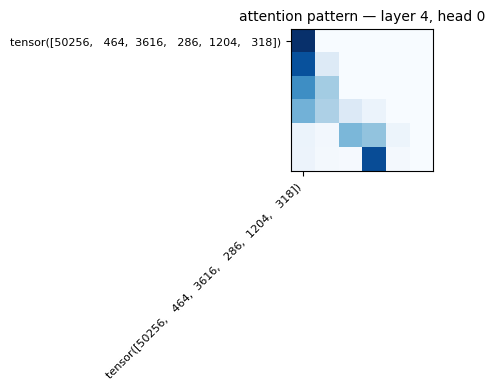

In [ ]:
head_1 = cache["attn", 4, "pattern"]
print (head_1)
print(model.to_str_tokens(tokens))
viz (cache, "pattern", layer=4, head=0)

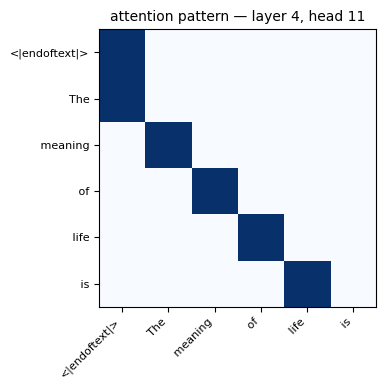

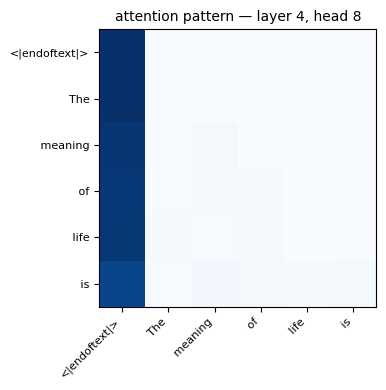

In [ ]:
str_tokens = model.to_str_tokens(tokens)
viz(cache, "pattern", layer=4, head=11)  # previous token head
viz(cache, "pattern", layer=4, head=8)   # attention sink head

In [ ]:
prompts = [
    "The meaning of life is",
    "The cat sat on the mat",
    "The president of the United States",
]

for prompt in prompts:
    tokens = model.to_tokens(prompt)
    logits, cache = model.run_with_cache(tokens)
    pattern = cache["blocks.0.attn.hook_pattern"][0]  # [12, seq, seq]
    str_tokens = model.to_str_tokens(tokens)

    print(f"\nPrompt: '{prompt}'")
    print(f"Tokens: {str_tokens}")
    print(f"Head 0 — last token attention: {pattern[0, -1].detach().numpy().round(3)}")
    print(f"Head 1 — last token attention: {pattern[1, -1].detach().numpy().round(3)}")